#                                          加载三个分类器并评估

## 1、导入依赖

In [1]:
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
# ✅ 重启后第一件事：禁用Eager模式（ART要求）
tf.compat.v1.disable_eager_execution()

from tensorflow.keras.models import load_model
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers.legacy import SGD

from art import config
from art.utils import load_dataset, get_file
from art.estimators.classification import KerasClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("TensorFlow版本:", tf.__version__)
print("Eager模式:", tf.executing_eagerly())  # 应该输出False

TensorFlow版本: 2.10.0
Eager模式: False


## 2、加载数据

In [2]:
import h5py
(x_train, y_train), (x_test, y_test), min_, max_ = load_dataset('mnist')

## 3、加载分类器

首先加载普通分类器

In [5]:
path = get_file('mnist_cnn_original.h5', extract=False, path=config.ART_DATA_PATH,
                url='https://www.dropbox.com/s/p2nyzne9chcerid/mnist_cnn_original.h5?dl=1')
#path = './mnist_cnn_original.h5'
classifier_model = load_model(path)
classifier = KerasClassifier(clip_values=(min_, max_), model=classifier_model, use_logits=False)

在原始数据上进行评估

In [9]:
x_test_pred = np.argmax(classifier.predict(x_test), axis=1)
nb_correct_pred = np.sum(x_test_pred == np.argmax(y_test, axis=1))

print("=" * 50 + " 1. 普通分类器 - 原始数据 "+ "=" * 50)
print("正确分类: {}".format(nb_correct_pred))
print("错误分类: {}".format(len(x_test)-nb_correct_pred))
print("准确率: {:.2f}%".format(nb_correct_pred / len(x_test) * 100))

================================================== 1. 普通分类器 - 原始数据 ==================================================
正确分类: 9842
错误分类: 158
准确率: 98.42%


生成对抗样本 并评估模型在对抗样本上的防御成功率

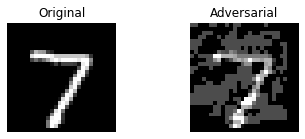

最大扰动: 0.30000001192092896


In [10]:
attacker = FastGradientMethod(classifier, eps=0.3)
x_test_adv = attacker.generate(x_test, y_test)

# 显示原始样本 vs 对抗样本
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Adversarial")
plt.imshow(x_test_adv[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

# 打印扰动大小
print("最大扰动:", np.max(np.abs(x_test_adv[:1] - x_test[:1])))

In [11]:
x_test_adv_pred = np.argmax(classifier.predict(x_test_adv), axis=1)
nb_correct_adv_pred = np.sum(x_test_adv_pred == np.argmax(y_test, axis=1))

print("对抗测试数据：")
print("正确分类: {}".format(nb_correct_adv_pred))
print("错误分类: {}".format(len(x_test_adv)-nb_correct_adv_pred))

对抗测试数据：
正确分类: 351
错误分类: 9649


加载BIM/PGD训练的模型

In [13]:
path_old = get_file('mnist_cnn_robust.h5', extract=False, path=config.ART_DATA_PATH,
                    url='https://www.dropbox.com/s/yutsncaniiy5uy8/mnist_cnn_robust.h5?dl=1')
#path = ''
robust_classifier_model_old = load_model(path_old)
robust_classifier_old = KerasClassifier(
    clip_values=(min_, max_), model=robust_classifier_model_old, use_logits=False
)

x_test_old_pred = np.argmax(robust_classifier_old.predict(x_test), axis=1)
nb_correct_old = np.sum(x_test_old_pred == np.argmax(y_test, axis=1))
print("=" * 50 + " 2. BIM/PGD鲁棒分类器 - 原始数据 "+ "=" * 50)
print("正确分类: {}".format(nb_correct_old))
print("错误分类: {}".format(len(x_test)-nb_correct_pred))
print("准确率: {:.2f}%".format(nb_correct_old / len(x_test) * 100))

================================================== 2. BIM/PGD鲁棒分类器 - 原始数据 ==================================================
正确分类: 9736
错误分类: 158
准确率: 97.36%


BIM/PGD训练的模型在对抗样本上的防御成功率

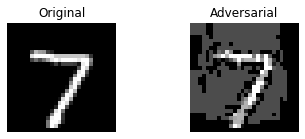

最大扰动: 0.30000001192092896


In [15]:
attacker_robust = FastGradientMethod(robust_classifier_old, eps=0.3)
x_test_adv_robust = attacker_robust.generate(x_test, y_test)

# 显示原始样本 vs 对抗样本
plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Adversarial")
plt.imshow(x_test_adv_robust[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

# 打印扰动大小
print("最大扰动:", np.max(np.abs(x_test_adv_robust[:1] - x_test[:1])))

In [16]:
x_test_adv_robust_pred = np.argmax(robust_classifier_old.predict(x_test_adv_robust), axis=1)
nb_correct_adv_robust_pred = np.sum(x_test_adv_robust_pred == np.argmax(y_test, axis=1))

print("对抗测试数据：")
print("正确分类：{}".format(nb_correct_adv_robust_pred))
print("错误分类：{}".format(len(x_test_adv_robust)-nb_correct_adv_robust_pred))

对抗测试数据：
正确分类：8688
错误分类：1312


加载训练好的TRADES模型

In [19]:
# 加载训练好的TRADES模型
trades_model_loaded = load_model('./trades_mnist_model.h5')

trades_classifier = KerasClassifier(
    clip_values=(min_, max_),
    model=trades_model_loaded,
    use_logits=False
)

# 评估原始数据
x_test_trades_pred = np.argmax(trades_classifier.predict(x_test), axis=1)
nb_correct_clean_trades = np.sum(x_test_trades_pred == np.argmax(y_test, axis=1))

print("=" * 50 + " 3. TRADES鲁棒分类器 - 原始数据 "+ "=" * 50)
print("正确分类: {}".format(nb_correct_clean_trades))
print("错误分类: {}".format(len(x_test) - nb_correct_clean_trades))
print("准确率: {:.2f}%".format(nb_correct_clean_trades / len(x_test) * 100))

================================================== 3. TRADES鲁棒分类器 - 原始数据 ==================================================
正确分类: 9617
错误分类: 383
准确率: 96.17%


TRADES训练的模型在对抗样本上的防御成功率

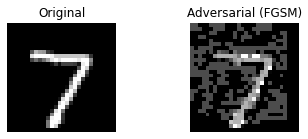

In [18]:
attacker_fgsm = FastGradientMethod(trades_classifier, eps=0.3)
x_test_adv_trades = attacker_fgsm.generate(x_test, y_test)

plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Adversarial (FGSM)")
plt.imshow(x_test_adv_trades[0].squeeze(), cmap='gray')
plt.axis('off')
plt.show()

In [21]:
x_test_adv_trades_pred = np.argmax(trades_classifier.predict(x_test_adv_trades), axis=1)
nb_correct_adv_trades  = np.sum(x_test_adv_trades_pred == np.argmax(y_test, axis=1))

print("=== TRADES模型 - FGSM对抗样本 ===")
print("正确分类: {}".format(nb_correct_adv_trades))
print("错误分类: {}".format(len(x_test_adv_trades) - nb_correct_adv_trades))
print("防御准确率: {:.2f}%".format(nb_correct_adv_trades / len(x_test) * 100))

=== TRADES模型 - FGSM对抗样本 ===
正确分类: 7407
错误分类: 2593
防御准确率: 74.07%


## 4、PGD攻击下三模型对比

In [ ]:
eps_range = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
nb_correct_original_list = []
nb_correct_old_list      = []
nb_correct_trades_list   = []
nb_samples = 100

print("开始PGD多eps评估，请稍候...")

for eps in eps_range:
    # 普通模型
    atk = ProjectedGradientDescent(
        estimator=classifier, eps=eps,
        eps_step=0.01, max_iter=200, verbose=False
    )
    x_adv = atk.generate(x_test[:nb_samples], y_test[:nb_samples])
    pred  = np.argmax(classifier.predict(x_adv), axis=1)
    nb_correct_original_list.append(
        np.sum(pred == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples
    )

    # 旧鲁棒模型
    atk_old = ProjectedGradientDescent(
        estimator=robust_classifier_old, eps=eps,
        eps_step=0.01, max_iter=200, verbose=False
    )
    x_adv_old = atk_old.generate(x_test[:nb_samples], y_test[:nb_samples])
    pred_old  = np.argmax(robust_classifier_old.predict(x_adv_old), axis=1)
    nb_correct_old_list.append(
        np.sum(pred_old == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples
    )

    # TRADES模型
    atk_trades = ProjectedGradientDescent(
        estimator=trades_classifier, eps=eps,
        eps_step=0.01, max_iter=40,
        num_random_init=1, verbose=False
    )
    x_adv_trades = atk_trades.generate(x_test[:nb_samples], y_test[:nb_samples])
    pred_trades  = np.argmax(trades_classifier.predict(x_adv_trades), axis=1)
    nb_correct_trades_list.append(
        np.sum(pred_trades == np.argmax(y_test[:nb_samples], axis=1)) / nb_samples
    )

    print("eps={:.2f} 完成".format(eps))

eps_range_plot           = [0] + eps_range
nb_correct_original_list = [nb_correct_pred / 10000]         + nb_correct_original_list
nb_correct_old_list      = [nb_correct_old / 10000]          + nb_correct_old_list
nb_correct_trades_list   = [nb_correct_clean_trades / 10000] + nb_correct_trades_list

print("评估完成！")

In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei']
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(eps_range_plot, nb_correct_original_list, 'b--', label='普通CNN（无防御）')
ax.plot(eps_range_plot, nb_correct_old_list,      'r--', label='旧鲁棒CNN（BIM训练）')
ax.plot(eps_range_plot, nb_correct_trades_list,   'g-',  label='TRADES鲁棒CNN（论文官方设置）')

ax.legend(loc='upper right', shadow=True, fontsize=11)
plt.xlabel('扰动大小（eps，L-无穷范数）')
plt.ylabel('分类准确率')
plt.title('TRADES vs 普通对抗训练 鲁棒性对比')
plt.savefig('output_trades_final.jpg', format='jpg', bbox_inches='tight', dpi=500)
plt.show()